# Project Setup: Importing Libraries

Welcome to the initialization phase of the project.  
In this section, we import all essential libraries required for data processing, visualization, modeling, and evaluation.

---

## Core Libraries

### 🔹 System & Utilities
- `os`, `sys` → File handling & system operations  
- `json` → Working with JSON data  
- `functools` → Optimization utilities (`lru_cache`)  

### 🔹 Data Handling
- `numpy` → Numerical computations  
- `pandas` → Data manipulation & analysis  

### 🔹 Data Visualization
- `matplotlib` → Basic plotting  
- `seaborn` → Advanced statistical visualization  

---

## Machine Learning Pipeline

### 🔹 Preprocessing
- Handling missing values → `SimpleImputer`  
- Encoding categorical variables → `OneHotEncoder`  
- Feature scaling → `StandardScaler`  

### 🔹 Pipeline & Transformation
- `Pipeline` → Streamlined workflow  
- `ColumnTransformer` → Column-wise transformations  

---

## Models Used

We experiment with multiple models to ensure optimal performance:

-  Logistic Regression → Baseline model  
-  Random Forest → Bagging-based ensemble  
-  Gradient Boosting → Sequential boosting model  
-  XGBoost → Advanced optimized boosting algorithm  

---

## Model Selection & Evaluation

### 🔹 Model Selection
- `train_test_split` → Data splitting  
- `RandomizedSearchCV` → Hyperparameter tuning  

### 🔹 Evaluation Metrics
- `accuracy_score` → Overall correctness  
- `classification_report` → Precision, Recall, F1-score  
- `roc_auc_score` → Model discrimination ability  

---

## Additional Tools

- `joblib` → Model saving/loading  
- `shap` → Model explainability  

---

In [1]:
# System & Utilities
import os
import sys
import json
from functools import lru_cache

# Data Handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model Persistence & Explainability
import joblib
import shap

# Machine Learning - Preprocessing
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Machine Learning - Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# Evaluation Metrics
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

#  Data Loading 

This section initializes and loads all required datasets from the local directory for analysis and modeling.

---

##  Data Source
- Directory: `dataset/`
- Format: CSV files loaded using `pandas`

---

##  Datasets

- **courses.csv**  
  Course and module metadata  

- **studentInfo.csv**  
  Student demographics and final outcomes  

- **studentAssessment.csv**  
  Student assessment scores  

- **studentVle.csv**  
  Student interaction with VLE (online learning platform)  

- **assessments.csv**  
  Assessment details (type, weight, deadlines)  

---

##  Purpose
These datasets collectively enable:
- Analysis of student performance  
- Evaluation of engagement patterns  
- Development of predictive models  

---

In [2]:
# Relative Path of the Dataset
data_dir= "/kaggle/input/datasets/neurocipher/student-dataset/dataset"

In [3]:
courses = pd.read_csv(os.path.join(data_dir, "courses.csv"))
student_info = pd.read_csv(os.path.join(data_dir, "studentInfo.csv"))
student_assessment = pd.read_csv(os.path.join(data_dir, "studentAssessment.csv"))
student_vle = pd.read_csv(os.path.join(data_dir, "studentVle.csv"))
assessments = pd.read_csv(os.path.join(data_dir, "assessments.csv"))        

# Data Overview (Initial Inspection)

This section performs a quick inspection of all loaded datasets to understand their structure, size, and basic properties.

---

##  Objectives
- Check dataset dimensions  
- View sample records  
- Inspect data types  
- Identify missing values  
- Get a high-level statistical summary  

---

>  This step helps in identifying data quality issues early before preprocessing and modeling.

In [4]:
# Dataset Glimpse Function
def dataset_overview(name, df):
    print(f"\n{'='*50}")
    print(f" Dataset: {name}")
    print(f"{'='*50}")
    
    print("\n Shape:",df.shape)
    
    print("\n :::Data Types:::\n")
    print(df.dtypes)
    
    print("\n :::Missing Values:::\n")
    print(df.isnull().sum())
    
    print("\n :::Sample Data:::\n")
    display(df.head())
    
    print("\n :::Statistical Summary:::\n")
    display(df.describe(include='all'))

# Apply to All Datasets
datasets = {
    "Courses": courses,
    "Student Info": student_info,
    "Student Assessment": student_assessment,
    "Student VLE": student_vle,
    "Assessments": assessments
}

for name, df in datasets.items():
    dataset_overview(name, df)


 Dataset: Courses

 Shape: (22, 3)

 :::Data Types:::

code_module                   object
code_presentation             object
module_presentation_length     int64
dtype: object

 :::Missing Values:::

code_module                   0
code_presentation             0
module_presentation_length    0
dtype: int64

 :::Sample Data:::



,code_module,code_presentation,module_presentation_length
0,AAA,2013J,268
1,AAA,2014J,269
2,BBB,2013J,268
3,BBB,2014J,262
4,BBB,2013B,240



 :::Statistical Summary:::



,code_module,code_presentation,module_presentation_length
count,22,22,22.000000
unique,7,4,NaN
top,BBB,2014J,NaN
freq,4,7,NaN
mean,NaN,NaN,255.545455
std,NaN,NaN,13.654677
min,NaN,NaN,234.000000
25%,NaN,NaN,241.000000
50%,NaN,NaN,261.500000
75%,NaN,NaN,268.000000



 Dataset: Student Info

 Shape: (32593, 12)

 :::Data Types:::

code_module             object
code_presentation       object
id_student               int64
gender                  object
region                  object
highest_education       object
imd_band                object
age_band                object
num_of_prev_attempts     int64
studied_credits          int64
disability              object
final_result            object
dtype: object

 :::Missing Values:::

code_module                0
code_presentation          0
id_student                 0
gender                     0
region                     0
highest_education          0
imd_band                1111
age_band                   0
num_of_prev_attempts       0
studied_credits            0
disability                 0
final_result               0
dtype: int64

 :::Sample Data:::



...

,code_module,code_presentation,id_student,id_site,date,sum_click
count,10655280,10655280,1.065528e+07,1.065528e+07,1.065528e+07,1.065528e+07
unique,7,4,NaN,NaN,NaN,NaN
top,FFF,2014J,NaN,NaN,NaN,NaN
freq,4014499,3619452,NaN,NaN,NaN,NaN
mean,NaN,NaN,7.333336e+05,7.383234e+05,9.517400e+01,3.716946e+00
std,NaN,NaN,5.827060e+05,1.312196e+05,7.607130e+01,8.849047e+00
min,NaN,NaN,6.516000e+03,5.267210e+05,-2.500000e+01,1.000000e+00
25%,NaN,NaN,5.077430e+05,6.735190e+05,2.500000e+01,1.000000e+00
50%,NaN,NaN,5.882360e+05,7.300690e+05,8.600000e+01,2.000000e+00
75%,NaN,NaN,6.464840e+05,8.770300e+05,1.560000e+02,3.000000e+00



 Dataset: Assessments

 Shape: (206, 6)

 :::Data Types:::

code_module           object
code_presentation     object
id_assessment          int64
assessment_type       object
date                 float64
weight               float64
dtype: object

 :::Missing Values:::

code_module           0
code_presentation     0
id_assessment         0
assessment_type       0
date                 11
weight                0
dtype: int64

 :::Sample Data:::



,code_module,code_presentation,id_assessment,assessment_type,date,weight
0,AAA,2013J,1752,TMA,19.0,10.0
1,AAA,2013J,1753,TMA,54.0,20.0
2,AAA,2013J,1754,TMA,117.0,20.0
3,AAA,2013J,1755,TMA,166.0,20.0
4,AAA,2013J,1756,TMA,215.0,30.0



 :::Statistical Summary:::



,code_module,code_presentation,id_assessment,assessment_type,date,weight
count,206,206,206.000000,206,195.000000,206.000000
unique,7,4,NaN,3,NaN,NaN
top,FFF,2014J,NaN,TMA,NaN,NaN
freq,52,57,NaN,106,NaN,NaN
mean,NaN,NaN,26473.975728,NaN,145.005128,20.873786
std,NaN,NaN,10098.625521,NaN,76.001119,30.384224
min,NaN,NaN,1752.000000,NaN,12.000000,0.000000
25%,NaN,NaN,15023.250000,NaN,71.000000,0.000000
50%,NaN,NaN,25364.500000,NaN,152.000000,12.500000
75%,NaN,NaN,34891.750000,NaN,222.000000,24.250000


#  Data Integration: Student & Course Data

This step merges student-level information with course metadata to create a unified dataset for downstream analysis.

---

##  Operation
- **Left Join** between:
  - `student_info` (primary dataset)
  - `courses` (reference dataset)

- **Join Keys**:
  - `code_module`
  - `code_presentation`

---

##  Join Details
- **Type**: `left`  
  → Ensures all student records are retained  

- **Validation**: `many_to_one`  
  → Each student record maps to a single course entry  

---

##  Outcome
The resulting dataset:
- Enriches student records with course-related attributes  
- Preserves data integrity through join validation  
- Serves as a base for feature engineering and modeling  

---

In [5]:
data = student_info.merge(
            courses,
            on=["code_module", "code_presentation"],
            how="left",
            validate="many_to_one")

In [6]:
data.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,module_presentation_length
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,268
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,268
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,268
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,268
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,268


# Target Variable Definition

This step defines the target variable for the predictive modeling task by transforming the final student outcome into a binary classification label.

---

## Transformation
The `final_result` column is mapped to a binary target:

- **1 (Positive Class)**:
  - Pass
  - Distinction  

- **0 (Negative Class)**:
  - Fail
  - Withdrawn  

---

##  Objective
- Convert categorical outcomes into a machine-learning-friendly format  
- Frame the problem as a **binary classification task**  
- Enable prediction of student success vs. non-success  

---

## Note
- This mapping assumes **Pass and Distinction** represent successful outcomes  
- **Fail and Withdrawn** are treated as unsuccessful outcomes for modeling purposes  

---

In [7]:
data["target"] = data["final_result"].map({
            "Pass": 1,
            "Distinction": 1,
            "Fail": 0,
            "Withdrawn": 0})

In [8]:
# Drops rows where target couldn't be mapped (just in case)
data = data.dropna(subset=['target'])        

# Feature Engineering: Behavioral & Academic Metrics

This step constructs student-level features from interaction (VLE) and assessment data to capture both engagement and academic performance.

---

## Behavioral Features (VLE)

Derived from student interaction logs:

- **total_clicks**  
  Total number of VLE interactions  

- **active_days**  
  Number of unique days with activity  

- **avg_clicks_per_day**  
  Average daily interactions  

- **activity_span**  
  Time span between first and last activity  

---

## Academic Feature (Assessment)

Derived from assessment records:

- **avg_assignment_score**  
  Average score across all submitted assessments  

---

## Rationale

- Behavioral features capture **engagement patterns and consistency**  
- Academic features capture **performance level**  
- Combining both provides a **holistic view of student behavior**  

---

## Objective

- Transform raw logs into structured, student-level features  
- Enable predictive modeling of student outcomes using both **engagement** and **performance signals**  

---

In [9]:
# Behavioral Features (VLE)
vle = student_vle.copy()
total_clicks = vle.groupby("id_student", as_index=False)["sum_click"].sum().rename(columns={"sum_click": "total_clicks"})
active_days = vle.groupby("id_student", as_index=False)["date"].nunique().rename(columns={"date": "active_days"})
avg_clicks = vle.groupby("id_student", as_index=False)["sum_click"].mean().rename(columns={"sum_click": "avg_clicks_per_day"})
        
activity_span = vle.groupby("id_student")["date"].agg(["min", "max"]).reset_index()
activity_span["activity_span"] = activity_span["max"] - activity_span["min"]
activity_span = activity_span[["id_student", "activity_span"]]
        
# Academic Feature (Assessment)
assessment = student_assessment.copy()
avg_score = assessment.groupby("id_student", as_index=False)["score"].mean().rename(columns={"score": "avg_assignment_score"})

# Feature Consolidation

This step integrates all engineered features into the main dataset by merging them at the student level.

---

## Operation
Sequential **left joins** are performed on `id_student` to combine:

- Behavioral features:
  - `total_clicks`
  - `active_days`
  - `avg_clicks_per_day`
  - `activity_span`

- Academic feature:
  - `avg_assignment_score`

---

## Join Details
- **Key**: `id_student`  
- **Type**: `left`  
  → Ensures all base records are preserved  

---

## Outcome
- A unified dataset with enriched feature space  
- Each row represents a student with both behavioral and academic attributes  
- Ready for preprocessing and model training  

---

##  Note
- Missing values may arise for students with no recorded activity or assessments  
- These will be handled in the preprocessing stage  

---

In [10]:
# Merge all
data = data.merge(total_clicks, on="id_student", how="left")
data = data.merge(active_days, on="id_student", how="left")
data = data.merge(avg_clicks, on="id_student", how="left")
data = data.merge(activity_span, on="id_student", how="left")
data = data.merge(avg_score, on="id_student", how="left")

In [11]:
data.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,module_presentation_length,target,total_clicks,active_days,avg_clicks_per_day,activity_span,avg_assignment_score
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,268,1,934.0,40.0,4.765306,258.0,82.0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,268,1,1435.0,80.0,3.337209,249.0,66.4
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,268,0,281.0,12.0,3.697368,22.0,NaN
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,268,1,2158.0,123.0,3.254902,274.0,76.0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,268,1,1034.0,70.0,2.937500,257.0,54.4


# **Instead of fillna(0) for everything, we leave it as NaN and let the Scikit-learn Pipeline handle it using SimpleImputer**

# Feature Selection & Target Separation

This step prepares the dataset for modeling by removing leakage-prone and identifier columns, and separating features from the target variable.

---

## Operation

- **Columns Dropped**:
  - `final_result` → Source of target (prevents data leakage)  
  - `id_student` → Unique identifier (non-informative for modeling)  

- **Feature Matrix (`X`)**:
  - All remaining columns after exclusions  

- **Target Vector (`y`)**:
  - `target` column cast to integer type  

---

##  Data Leakage Prevention
- `final_result` is excluded as it directly determines the target  
- Including it would lead to artificially high model performance  

---

##  Outcome
- Clean feature set (`X`) ready for preprocessing  
- Target variable (`y`) ready for training  

---

In [12]:
# Drop leakage and identifier columns
drop_cols = ["final_result", "id_student"]
X = data.drop(columns=drop_cols + ["target"], errors="ignore")
y = data["target"].astype(int)        

# Train–Test Split

This step partitions the dataset into training and testing subsets to evaluate model performance on unseen data.

---

## Configuration

- **Test Size**: `20%`  
- **Random State**: `42` (ensures reproducibility)  
- **Stratification**: Applied on target variable (`y`)  

---

## Rationale

- **Stratified Sampling** ensures that class distribution is preserved in both training and testing sets  
- Helps prevent bias, especially in imbalanced classification problems  

---

## Outcome

- `X_train`, `y_train` → Used for model training  
- `X_test`, `y_test` → Used for model evaluation  

---

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#  Model Selection & Hyperparameter Tuning

This step evaluates multiple machine learning models and selects the best-performing one using cross-validated hyperparameter tuning.

---

##  Models Evaluated

- Logistic Regression  
- Random Forest Classifier  
- Gradient Boosting Classifier  
- XGBoost Classifier  

---

##  Approach

- Each model is integrated into a unified **pipeline** with preprocessing  
- **RandomizedSearchCV** is used for hyperparameter tuning  
- **3-fold cross-validation** ensures robust performance estimation  

---

##  Evaluation Metric

- **Primary Metric**: ROC-AUC  
  → Measures the model’s ability to distinguish between classes  

- Additional metrics:
  - Accuracy  
  - Classification Report  

---

##  Process

- Train each model with randomized hyperparameter search  
- Evaluate performance on the test set  
- Store results for comparison  

---

##  Model Selection

- Models are ranked based on **ROC-AUC score**  
- The best-performing model is selected for further analysis and deployment  

---

##  Outcome

- Identification of the most effective model  
- Optimized hyperparameters for improved performance  
- A reproducible and scalable model selection framework  

---

In [14]:
def build_pipeline(X, model):
    num_cols = X.select_dtypes(include=["int64", "float64"]).columns
    cat_cols = X.select_dtypes(include=["object"]).columns

    num_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())])

    cat_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))])

    preprocessor = ColumnTransformer([
        ("num", num_pipeline, num_cols),
        ("cat", cat_pipeline, cat_cols)])

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)])

    return pipeline, num_cols, cat_cols

In [15]:
# Models + Param Grids
models_config = {
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=1000),
        "params": {
            "model__C": [0.01, 0.1, 1, 10],
            "model__solver": ["lbfgs"]}},
    
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "model__n_estimators": [100, 200],
            "model__max_depth": [None, 5, 10],
            "model__min_samples_split": [2, 5]}},
    
    "Gradient Boosting": {
        "model": GradientBoostingClassifier(random_state=42),
        "params": {
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.05, 0.1],
            "model__max_depth": [3, 5]}},
    
    "XGBoost": {
        "model": XGBClassifier(
            random_state=42,
            eval_metric='logloss',
            base_score=0.5
        ),
        "params": {
            "model__n_estimators": [100, 200, 300],
            "model__learning_rate": [0.01, 0.05, 0.1],
            "model__max_depth": [3, 5, 7],
            "model__subsample": [0.8, 1.0],}}}

In [16]:
# Model Comparison Loop
results = []

for name, config in models_config.items():
    print(f"\n Training: {name}...")
    
    model = config["model"]
    param_grid = config["params"]
    
    # Build pipeline dynamically
    pipeline, _, _ = build_pipeline(X_train, model)
    
    search = RandomizedSearchCV(
        pipeline,
        param_distributions=param_grid,
        n_iter=10,
        scoring='roc_auc',
        cv=3,
        random_state=42,
        n_jobs=-1,
        verbose=0)
    
    search.fit(X_train, y_train)
    
    best_model = search.best_estimator_
    
    # Evaluate
    y_pred = best_model.predict(X_test)
    y_prob = best_model.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    
    results.append({
        "Model": name,
        "Best Params": search.best_params_,
        "Accuracy": acc,
        "ROC-AUC": roc
    })


 Training: Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=10. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(



 Training: Random Forest...

 Training: Gradient Boosting...


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(



 Training: XGBoost...


In [17]:
# Results Table
results_df = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False)

print("\n Model Comparison Results:")
display(results_df)


 Model Comparison Results:


,Model,Best Params,Accuracy,ROC-AUC
3,XGBoost,"{'model__subsample': 0.8, 'model__n_estimators...",0.898451,0.962446
2,Gradient Boosting,"{'model__n_estimators': 200, 'model__max_depth...",0.894462,0.961688
1,Random Forest,"{'model__n_estimators': 200, 'model__min_sampl...",0.897684,0.959762
0,Logistic Regression,"{'model__solver': 'lbfgs', 'model__C': 0.1}",0.821138,0.915267


#  Model Evaluation

This step evaluates the performance of the selected model on the test dataset using standard classification metrics.

---

##  Predictions

- `y_pred` → Predicted class labels  
- `y_prob` → Predicted probabilities for the positive class  

---

##  Evaluation Metrics

- **Accuracy**  
  → Overall proportion of correct predictions  

- **ROC-AUC Score**  
  → Measures the model’s ability to distinguish between classes  

- **Classification Report**  
  → Provides detailed metrics:
  - Precision  
  - Recall  
  - F1-score  
  - Support  

---

##  Objective

- Assess model performance on unseen data  
- Evaluate both classification accuracy and probabilistic ranking ability  
- Identify strengths and weaknesses across classes  

---

##  Interpretation

- Higher **ROC-AUC** indicates better class separation  
- Classification report helps analyze class-wise performance  

---

In [18]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

In [19]:
acc = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

In [20]:
print(f"Accuracy: {acc*100:.4f} %")
print(f"ROC AUC: {roc_auc:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 89.8451 %
ROC AUC: 0.9624

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.87      0.90      3442
           1       0.86      0.93      0.90      3077

    accuracy                           0.90      6519
   macro avg       0.90      0.90      0.90      6519
weighted avg       0.90      0.90      0.90      6519



# Model Persistence & Artifact Saving

This step saves the trained model pipeline and associated metadata for future use, such as inference or deployment.

---

##  Artifacts Saved

- **Model Pipeline (`.pkl`)**  
  - Serialized using `joblib`  
  - Includes preprocessing and trained model  

- **Feature Columns (`.json`)**  
  - Stores the list of input feature names  
  - Ensures consistency during inference  

---

##  Storage Details

- **Directory**: User-defined base path  
- **Formats**:
  - Model → `.pkl`  
  - Metadata → `.json`  

---

##  Objective

- Enable reuse of the trained model without retraining  
- Maintain consistency between training and inference pipelines  
- Support deployment and reproducibility  

---

In [21]:
base_dir="/kaggle/working/"

In [22]:
model_path = os.path.join(base_dir, "model_pipeline.pkl")
joblib.dump(best_model, model_path)

['/kaggle/working/model_pipeline.pkl']

In [23]:
feature_columns = list(X.columns)
columns_path = os.path.join(base_dir, "feature_columns.json")
with open(columns_path, "w") as f:
    json.dump(feature_columns, f)
        
print(f"Artifacts saved to {model_path} and {columns_path}")

Artifacts saved to /kaggle/working/model_pipeline.pkl and /kaggle/working/feature_columns.json


#  Inference Pipeline & Prediction System

This section defines the runtime system for loading trained artifacts and generating predictions on new input data.

---

##  Components

### 🔹 Artifact Loader (`load_system`)
- Loads:
  - Trained model pipeline (`.pkl`)
  - Feature schema (`feature_columns.json`)  
- Uses caching (`lru_cache`) to optimize repeated calls  
- Validates artifact availability before loading  

---

### 🔹 Prediction Function (`predict_student`)
- Accepts raw input data as a dictionary  
- Converts input into a structured DataFrame  
- Ensures feature consistency:
  - Adds missing columns with default values  
  - Aligns column order with training schema  

---

##  Prediction Flow

1. Load model and feature schema  
2. Prepare input data  
3. Apply preprocessing via pipeline  
4. Generate:
   - **Prediction (0/1)**  
   - **Probability score**  

---

##  Output

Returns a dictionary containing:
- `prediction` → Final class label  
- `success_probability` → Probability of positive class  
- `input_df` → Processed input  
- `pipeline` → Loaded model pipeline  
- `feature_columns` → Feature schema  

---

##  Objective

- Enable consistent and reliable predictions on new data  
- Ensure alignment between training and inference pipelines  
- Support deployment-ready prediction workflow  

---

In [24]:
@lru_cache(maxsize=1)
def load_system():
    pipeline_path = os.path.join(base_dir, "model_pipeline.pkl")
    features_path = os.path.join(base_dir, "feature_columns.json")
    
    if not os.path.exists(pipeline_path):
        raise FileNotFoundError(f"Model pipeline not found at {pipeline_path}. Please run src/model.py first.")
        
    pipeline = joblib.load(pipeline_path)
    with open(features_path, "r") as f:
        feature_columns = json.load(f)
        
    return pipeline, feature_columns

In [25]:
def predict_student(input_data):
    pipeline, feature_columns = load_system()
    
    input_df = pd.DataFrame([input_data])
    
    for col in feature_columns:
        if col not in input_df.columns:
            input_df[col] = 0
            
    input_df = input_df[feature_columns]
    
    prediction = pipeline.predict(input_df)[0]
    probability = pipeline.predict_proba(input_df)[0][1]
    
    return {
        "prediction": int(prediction),
        "success_probability": float(probability),
        "input_df": input_df,
        "pipeline": pipeline,
        "feature_columns": feature_columns
    }

#  Model Explainability & Actionable Insights

This section implements model interpretability using SHAP (SHapley Additive exPlanations) to understand feature contributions for individual predictions.

---

##  Explainability Pipeline

### 🔹 SHAP-Based Explanation (`explain_prediction`)
- Transforms input data using the trained preprocessing pipeline  
- Computes SHAP values to quantify feature contributions  
- Handles compatibility issues with fallback logic for model-specific constraints  
- Aggregates and ranks feature impacts  

---

##  Feature Contribution Analysis

- **Risk Factors**  
  Features with negative contribution to prediction (top 3)

- **Success Factors**  
  Features with positive contribution to prediction (top 3)

- **Expected Value**  
  Baseline model output before feature contributions  

---

##  Actionable Insights (`generate_actionable_insights`)

- Converts SHAP explanations into human-readable recommendations  
- Highlights:
  - Areas needing improvement  
  - Strong performance areas to maintain  

- Ensures interpretability for non-technical users  

---

##  Visualization (`get_shap_waterfall_plot`)

- Generates SHAP waterfall plot for individual prediction  
- Shows:
  - Contribution of each feature  
  - Direction and magnitude of impact  
- Handles:
  - Sparse/dense data conversion  
  - Multi-output SHAP values  
  - Feature alignment for stability  

---

##  Objective

- Provide transparency in model predictions  
- Enable data-driven decision-making  
- Bridge the gap between model output and user understanding  

---

In [26]:
def explain_prediction(pipeline, input_df):
    """
    Generate SHAP values for the prediction to explain feature importance.
    """
    preprocessor = pipeline.named_steps['preprocessor']
    model = pipeline.named_steps['model']
    
    X_transformed = preprocessor.transform(input_df)
    
    try:
        feature_names = preprocessor.get_feature_names_out()
    except AttributeError:
        feature_names = [f"Feature_{i}" for i in range(X_transformed.shape[1])]
    
    try:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_transformed)
        if isinstance(shap_values, list):
            shap_values = shap_values[1]  # take positive class
        expected_value = explainer.expected_value
        if isinstance(expected_value, (list, np.ndarray)):
            expected_value = expected_value[1]
    except Exception:
        # Fallback for XGBoost 2.0+ & SHAP parser issues
        importances = model.feature_importances_
        X_dense = X_transformed.toarray() if hasattr(X_transformed, 'toarray') else np.array(X_transformed)
        val_diffs = X_dense[0] - np.mean(X_dense[0])
        # scale importance up so its visually interpretable alongside expected 0.5 probability
        shap_values = [importances * val_diffs * 0.1]
        expected_value = 0.5
    
    
    # Ensure shap_values is numpy array
    if isinstance(shap_values, list):
        shap_values = shap_values[-1]  # take positive class
    shap_values = np.array(shap_values)
    shap_row = shap_values[0] if shap_values.ndim > 1 else shap_values

    importance_dict = dict(zip(feature_names, shap_row))
    
    clean_importance = {}
    for k, v in importance_dict.items():
        clean_name = k.split('__')[-1].replace('_', ' ').capitalize()
        if clean_name in clean_importance:
            clean_importance[clean_name] += v
        else:
            clean_importance[clean_name] = v
        
    sorted_importances = sorted(clean_importance.items(), key=lambda x: x[1])
    
    risk_factors = [item for item in sorted_importances if item[1] < -0.01][:3]
    success_factors = sorted([item for item in sorted_importances if item[1] > 0.01], key=lambda x: x[1], reverse=True)[:3]
    
    return {
        "risk_factors": risk_factors,
        "success_factors": success_factors,
        "expected_value": expected_value,
        "shap_values": shap_values,
        "feature_names": [f.split('__')[-1] for f in feature_names],
        "transformed_data": X_transformed
    }

In [27]:
def generate_actionable_insights(explanation):
    insights = []
    
    risk_factors = explanation.get('risk_factors', [])
    for factor, val in risk_factors:
        insights.append(f" **Improve {factor}**: (Impact metric: {val:.2f}) - This is dragging down your success probability.")
        
    success_factors = explanation.get('success_factors', [])
    for factor, val in success_factors:
        insights.append(f" **Strong {factor}**: (Impact metric: +{val:.2f}) - Great job, keep this up!")
        
    if not insights:
        insights.append(" Your metrics are stable without extreme outliers. Keep maintaining this consistent behavior.")
        
    return insights

In [28]:
def get_shap_waterfall_plot(explanation):
    # Ensure values is a flat 1D array
    vals = explanation['shap_values']
    
    if isinstance(vals, list):
        vals = vals[-1]  # always take positive class safely
    
    # Slice first row and flatten
    shap_vals = vals[0] if len(vals.shape) > 1 else vals
    shap_vals = np.array(shap_vals).flatten()
    
    # Ensure data is a flat dense array
    data_raw = explanation['transformed_data']
    if hasattr(data_raw, "toarray"):
        data_dense = data_raw.toarray()[0]
    else:
        # If it's already an array, just slice first row
        data_dense = data_raw[0] if len(data_raw.shape) > 1 else data_raw
    data_dense = np.array(data_dense).flatten()
    
    # Handle base values (expected_value)
    base_val = explanation['expected_value']
    if isinstance(base_val, (list, np.ndarray)):
        base_val = base_val[1] if len(base_val) > 1 else base_val[0]

    # Align feature names with values length to prevent IndexError
    f_names = list(explanation['feature_names'])
    if len(f_names) > len(shap_vals):
        f_names = f_names[:len(shap_vals)]
    elif len(f_names) < len(shap_vals):
        f_names.extend([f"Feature {i}" for i in range(len(f_names), len(shap_vals))])

    # Construct the Explanation object
    shap_exp = shap.Explanation(
        values=shap_vals, 
        base_values=float(base_val), 
        data=data_dense, 
        feature_names=f_names
    )
    
    # Limit to top 10 features to ensure visual stability and avoid tick label crashes
    fig, ax = plt.subplots(figsize=(8, 4))
    shap.plots.waterfall(shap_exp, max_display=10, show=False)
    plt.tight_layout()
    return fig

# Student Analysis & Recommendation Engine

This component provides a comprehensive analysis of a student's performance by combining prediction, behavioral assessment, simulation, and actionable recommendations.

---

##  Core Functionality

### 🔹 Prediction
- Uses the trained model to generate:
  - **Success Probability**
  - **Binary Prediction** (Success / At Risk)

---

##  Behavioral Analysis

### 🔹 Current Behavior
Extracts key engagement and performance metrics:
- Active study days  
- Total LMS interactions (clicks)  
- Average assignment score  

---

### 🔹 Target Behavior
Defines benchmark values representing successful students:
- Optimal engagement levels  
- Ideal academic performance  

---

### 🔹 Improvement Gap
Calculates the difference between current and target behavior:
- Additional study days required  
- Additional LMS engagement needed  
- Required improvement in assignment scores  

---

##  Personalized Study Plan

- Estimates **remaining time** in the course  
- Distributes required improvements into a **weekly plan**:
  - Study days per week  
  - LMS activity targets  

---

##  Risk Assessment

Classifies students based on predicted probability:
- **Low Risk** → High probability of success  
- **Moderate Risk** → Needs improvement  
- **High Risk** → At risk of failure  

---

## What-If Simulation

Simulates impact of improving individual factors:
- Increased study days  
- Improved assignment scores  
- Higher LMS engagement  

Also evaluates an **ideal scenario** where all target behaviors are achieved.

---

## Output

Returns a structured summary including:
- Prediction and risk level  
- Current vs target behavior  
- Required improvements  
- Simulation results  
- Weekly action plan  

---

##  Objective

- Translate model predictions into actionable insights  
- Provide personalized guidance for student improvement  
- Bridge the gap between analytics and real-world decision-making  

---

In [29]:
def analyze_student(student_input):
    # Base prediction
    result = predict_student(student_input)
    prob = result["success_probability"]
    prediction = result["prediction"]
    
    # Current Behavior
    current_behavior = {
        "active_days": student_input.get("active_days", 0),
        "total_clicks": student_input.get("total_clicks", 0),
        "avg_assignment_score": student_input.get("avg_assignment_score", 0)
    }
    
    # Target Behavior
    target_behavior = {
        "active_days": 89,
        "total_clicks": 1607,
        "avg_assignment_score": 79.8
    }
    
    improvement_needed = {
        "extra_days": max(0, round(target_behavior["active_days"] - current_behavior["active_days"])),
        "extra_clicks": max(0, round(target_behavior["total_clicks"] - current_behavior["total_clicks"])),
        "marks_improvement": max(0, round(target_behavior["avg_assignment_score"] - current_behavior["avg_assignment_score"], 1))
    }
    
    # Calculate Weekly Plan
    module_length = student_input.get("module_presentation_length", 268)
    activity_span = student_input.get("activity_span", 0)
    remaining_days = max(1, module_length - activity_span)
    remaining_weeks = max(1, round(remaining_days / 7))
    
    weekly_plan = {}
    if improvement_needed["extra_days"] > 0:
        weekly_plan["days_per_week"] = max(1, round(improvement_needed["extra_days"] / remaining_weeks))
    if improvement_needed["extra_clicks"] > 0:
        weekly_plan["clicks_per_week"] = max(1, round(improvement_needed["extra_clicks"] / remaining_weeks))
    
    if prob > 0.75:
        risk = "Low"
    elif prob > 0.4:
        risk = "Moderate"
    else:
        risk = "High"
        
    simulation = {}
    
    def simulate_change(feature):
        temp_input = student_input.copy()
        current = student_input.get(feature, 0)
        target = target_behavior.get(feature, current)
        
        gap = max(0, target - current)
        step = max(1, gap) # Jump directly to target to show real impact!
        
        new_value = current + step
        temp_input[feature] = new_value
        
        # Adjust derived features logically
        if temp_input.get("active_days", 0) > 0:
            temp_input["avg_clicks_per_day"] = temp_input["total_clicks"] / temp_input["active_days"]
        
        # An active student spans their learning over the module length
        # Roughly estimate activity_span based on active_days and module length
        if temp_input["active_days"] > 0:
            expected_span = min(temp_input.get("module_presentation_length", 268), temp_input["active_days"] * (268.0 / 89.0))
            temp_input["activity_span"] = max(temp_input.get("activity_span", 0), expected_span)
            
        sim_pred = predict_student(temp_input)
        return sim_pred["success_probability"]

    simulation["study_days"] = simulate_change("active_days")
    simulation["assignment"] = simulate_change("avg_assignment_score")
    simulation["lms"] = simulate_change("total_clicks")
    
    temp_ideal = student_input.copy()
    temp_ideal.update(target_behavior)
    if temp_ideal.get("active_days", 0) > 0:
        temp_ideal["avg_clicks_per_day"] = temp_ideal["total_clicks"] / temp_ideal["active_days"]
        
    expected_ideal_span = min(temp_ideal.get("module_presentation_length", 268), temp_ideal["active_days"] * (268.0 / 89.0))
    temp_ideal["activity_span"] = max(temp_ideal.get("activity_span", 0), expected_ideal_span)
        
    simulation["ideal"] = predict_student(temp_ideal)["success_probability"]
    
    prediction_label = "SUCCESS" if prediction == 1 else "AT RISK"
    
    return {
        "prediction": prediction_label,
        "success_probability": prob,
        "risk_level": risk,
        "current_behavior": current_behavior,
        "target_behavior": target_behavior,
        "improvement_needed": improvement_needed,
        "simulation": simulation,
        "remaining_weeks": remaining_weeks,
        "weekly_plan": weekly_plan,
        "pipeline": result.get("pipeline"),
        "input_df": result.get("input_df")
    }

# End-to-End System Demonstration

This section demonstrates the complete workflow of the student analysis system using a sample input.

---

## Execution Flow

- A sample student profile is defined with:
  - Demographic details  
  - Academic information  
  - Behavioral engagement metrics  

- The `analyze_student()` function is invoked to:
  - Generate prediction  
  - Assess risk level  
  - Analyze behavioral gaps  
  - Simulate improvement scenarios  
  - Provide actionable recommendations  

---

## Output Breakdown

### 🔹 Prediction Summary
- Final classification: **SUCCESS / AT RISK**  
- Predicted success probability  
- Risk level categorization  

---

### 🔹 Behavioral Comparison
- **Target Behavior** → Benchmarks for successful students  
- **Current Behavior** → Student’s present performance  

---

### 🔹 Improvement Analysis
- Required increase in:
  - Study days  
  - LMS engagement  
  - Assignment performance  

---

### 🔹 Simulation Results
- Impact of improving:
  - Study consistency  
  - Assignment scores  
  - LMS activity  

- Ideal scenario showing maximum achievable success probability  

---

### 🔹 Recommendations
- Personalized suggestions based on improvement gaps  
- Focus areas for maximizing success  

---

### 🔹 Weekly Study Plan
- Time-aware plan based on remaining course duration  
- Includes:
  - Study frequency targets  
  - Engagement goals  
  - Academic improvement focus  

---

##  Objective

- Validate the end-to-end pipeline  
- Demonstrate real-world applicability of the system  
- Translate model outputs into actionable, user-friendly insights  

---

##  Note

- This is a simulated example for demonstration purposes  
- Real-world performance may vary based on input data  

---

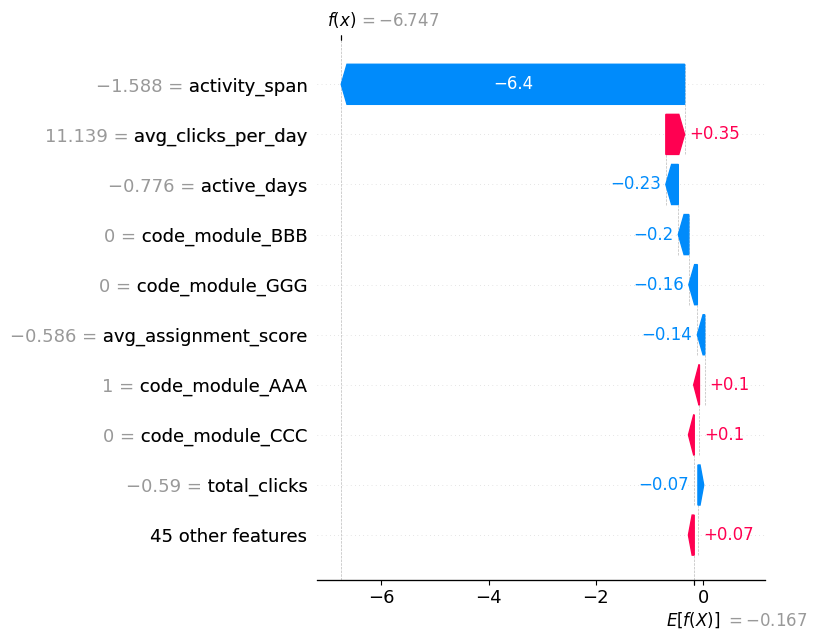

----- AI Exam Companion Result -----
Prediction: AT RISK
Predicted Success Probability: 0.0012
Risk Level: High

--- Target Behavior for Successful Students ---
Target active study days: 89
Target LMS clicks: 1607
Target assignment score: 79.8

--- Your Current Behavior ---
Active study days: 25
LMS clicks: 400
Assignment score: 65.0

--- Improvement Needed ---
Extra study days needed: 64
Extra LMS clicks needed: 1207
Assignment marks to improve: 14.8

--- Success Improvement Simulation ---
If you study 64 more days, success probability becomes: 0.9195
If assignment score improves by 14.8 marks, probability becomes: 0.0012
If LMS engagement increases by 1207 clicks, probability becomes: 0.0014

If you reach successful student behavior, success probability becomes: 0.9795

--- Recommendations ---
- Increase LMS activity by ~1207 more clicks
- Increase study days by ~64 more days
- Start studying earlier and maintain consistency
- Improve assignment score by ~14.8 marks

--- Your Persona

In [30]:
if __name__ == "__main__":
    sample_student = {
        "code_module": "AAA",
        "code_presentation": "2013J",
        "gender": "M",
        "region": "East Anglian Region",
        "highest_education": "HE Qualification",
        "imd_band": "50-60%",
        "age_band": "35-55",
        "num_of_prev_attempts": 0,
        "studied_credits": 60,
        "disability": "N",
        "module_presentation_length": 268,
        "total_clicks": 400,
        "active_days": 25,
        "avg_clicks_per_day": 16.0,
        "activity_span": 60,
        "avg_assignment_score": 65.0
    }
    
    res = analyze_student(sample_student)
    
    # ---------------- SHAP EXPLANATION ----------------
    explanation = explain_prediction(res["pipeline"], res["input_df"])
    fig = get_shap_waterfall_plot(explanation)
    plt.show()

    print("----- AI Exam Companion Result -----")
    print(f"Prediction: {res['prediction']}")
    print(f"Predicted Success Probability: {res['success_probability']:.4f}")
    print(f"Risk Level: {res['risk_level']}\n")

    # ---------------- TARGET ----------------
    print("--- Target Behavior for Successful Students ---")
    print(f"Target active study days: {res['target_behavior']['active_days']}")
    print(f"Target LMS clicks: {res['target_behavior']['total_clicks']}")
    print(f"Target assignment score: {res['target_behavior']['avg_assignment_score']}\n")

    # ---------------- CURRENT ----------------
    print("--- Your Current Behavior ---")
    print(f"Active study days: {res['current_behavior']['active_days']}")
    print(f"LMS clicks: {res['current_behavior']['total_clicks']}")
    print(f"Assignment score: {res['current_behavior']['avg_assignment_score']}")

    # ---------------- IMPROVEMENT ----------------
    print("\n--- Improvement Needed ---")
    print(f"Extra study days needed: {res['improvement_needed']['extra_days']}")
    print(f"Extra LMS clicks needed: {res['improvement_needed']['extra_clicks']}")
    print(f"Assignment marks to improve: {res['improvement_needed']['marks_improvement']}")

    # ---------------- SIMULATION ----------------
    print("\n--- Success Improvement Simulation ---")
    print(f"If you study {res['improvement_needed']['extra_days']} more days, success probability becomes: {res['simulation']['study_days']:.4f}")
    print(f"If assignment score improves by {res['improvement_needed']['marks_improvement']} marks, probability becomes: {res['simulation']['assignment']:.4f}")
    print(f"If LMS engagement increases by {res['improvement_needed']['extra_clicks']} clicks, probability becomes: {res['simulation']['lms']:.4f}")
    print(f"\nIf you reach successful student behavior, success probability becomes: {res['simulation']['ideal']:.4f}")

    # ---------------- RECOMMENDATIONS ----------------
    print("\n--- Recommendations ---")
    if res['improvement_needed']['extra_clicks'] > 0:
        print(f"- Increase LMS activity by ~{res['improvement_needed']['extra_clicks']} more clicks")
    if res['improvement_needed']['extra_days'] > 0:
        print(f"- Increase study days by ~{res['improvement_needed']['extra_days']} more days")
        print("- Start studying earlier and maintain consistency")
    if res['improvement_needed']['marks_improvement'] > 0:
        print(f"- Improve assignment score by ~{res['improvement_needed']['marks_improvement']} marks")

    # ---------------- WEEKLY STUDY PLAN ----------------
    if len(res['weekly_plan']) > 0 or res['improvement_needed']['marks_improvement'] > 0:
        print(f"\n--- Your Personalized Weekly Study Plan ({res['remaining_weeks']} weeks remaining) ---")
        if "days_per_week" in res['weekly_plan']:
            print(f"- Days to Study: Log in and study {res['weekly_plan']['days_per_week']} to {res['weekly_plan']['days_per_week'] + 1} days every week.")
        if "clicks_per_week" in res['weekly_plan']:
            print(f"- Engagement: Generate about {res['weekly_plan']['clicks_per_week']} clicks per week reading materials and taking quizzes.")
        if res['improvement_needed']['marks_improvement'] > 0:
            print(f"- Grades: Focus your study time deeply on assignments to raise your average by {res['improvement_needed']['marks_improvement']} marks.")


# **Thank You**